In [2]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
outbreak_num = 1
# outbreak_num = 103319
# outbreak_num = 451119
# outbreak_num = 467803
# outbreak_num = 485214
# outbreak_num = 631256
# outbreak_num = 739713
# outbreak_num = 823622
# outbreak_num = 890939
# outbreak_num = 995529

In [4]:
# Directories to input files
farm_shp_dir = f"input/boris_data/outbreak-{outbreak_num}/grid.geojson"
traj_csv_dir = f"input/boris_data/outbreak-{outbreak_num}/trajectory.csv"
gemeente_shp_dir = "input/gemeentes/corrected/Gemeentes2013TrMr.shp"

# Directories to output_files
output_dir = f"output/outbreak-{outbreak_num}"
preprocessed_farm_shp_dir = f"{output_dir}/preprocessed_farm.shp"
iv_table_dir = f"{output_dir}/iv_table.csv"

## Function definitions

In [5]:
# Function to transform the crs of farm grid to the crs of the gemeente
def transform_farm_grid_crs(
  farm_gdf,
  gemeente_gdf,
  transformed_farm_shp_dir = "output/farm_transformed_crs.shp",
  save_file=False
):
  if farm_gdf.crs != gemeente_gdf.crs:
    farm_gdf = farm_gdf.to_crs(gemeente_gdf.crs)

  if save_file == True:
    farm_gdf.to_file(transformed_farm_shp_dir)

  return farm_gdf


# Function to transform each farm polygon to centroids
def convert_farm_to_centroids(
  farm_gdf,
  farm_centroid_dir = "output/farm_centroid.shp",
  save_file = False
):

  farm_gdf["geometry"] = farm_gdf["geometry"].centroid

  if save_file == True:
    farm_gdf.to_file(farm_centroid_dir)

  return farm_gdf


# Function to add to each farm the gemeente ID of the gemeente they belong to
def add_gemeente_ids_to_farm_centroids(
  farm_gdf,
  gemeente_gdf,
  output_farm_dir = "output/farm_with_gm_id.shp",
  save_file = False
):
  # Spatial join to match grid points with gemeente geometries
  joined_gdf = gpd.sjoin(left_df= farm_gdf, right_df=gemeente_gdf[["OBJECTID", "geometry"]], how="left", predicate="within")
 
  # Assign the gemeente_id from the join result
  farm_gdf["gm_id"] = joined_gdf["OBJECTID"]

  # Saving file
  if save_file:
    farm_gdf.to_file(output_farm_dir)

  return farm_gdf

# Function to add to each farm the gemeente ID of the gemeente they belong to
def add_gemeente_names_to_farm_centroids(
  farm_gdf,
  gemeente_gdf,
  output_farm_dir = "output/farm_with_gm_id.shp",
  save_file = False
):
  # Spatial join to match grid points with gemeente geometries
  joined_gdf = gpd.sjoin(left_df= farm_gdf, right_df=gemeente_gdf[["gemeente", "geometry"]], how="left", predicate="within")
 
  # Assign the gemeente_id from the join result
  farm_gdf["name"] = joined_gdf["gemeente"]

  # Saving file
  if save_file:
    farm_gdf.to_file(output_farm_dir)

  return farm_gdf

def discard_farms_outside_nl(
  farm_gdf
):
  # Discarding farms that have NA for gm_id. This means these farms
  # are outside the NL
  farm_gdf = farm_gdf[farm_gdf["name"].notna()].copy()

  # Convert to integer type if no missing values are expected
  farm_gdf["name"] = farm_gdf["name"].astype("str")
  farm_gdf["node"] = farm_gdf["node"].astype("int")

  farm_gdf = farm_gdf[farm_gdf["node"] != 19271]

  return(farm_gdf)

In [6]:
# Function to transform the iv table so that each row represents the time and the
# columns are the
def create_iv_tables(
    traj_csv_dir,
    output_iv_table_dir="output/iv_table.csv",
    preprocessed_farm_dir="output/preprocessed_farm.shp"
):

    trajectory_data = pd.read_csv(traj_csv_dir)
    grid_df = gpd.read_file(preprocessed_farm_dir)

    # Pivot the data on time column so each time is on the row and the columns are the nodes' IV values
    iv_table = trajectory_data.pivot(index="time", columns="node", values="Iv").reset_index()

    # Removing the column index name
    iv_table.columns.name = None

    # Deleting columns corresponding to IV values for nodes that are not in preprocessed grid.
    # The nodes not present in preprocessed grid were outside of the country
    iv_table = iv_table[iv_table.columns.intersection(grid_df["node"].values)]

    iv_table.to_csv(output_iv_table_dir, index=False)

### Script to run preprocessing

In [ ]:
for dir in os.listdir('input/boris_data'):
    if dir.startswith('outbreak-'):
        outbreak_num = dir.split('-')[1]

    else:
       continue

    # Directories to input files
    farm_shp_dir = f"input/boris_data/outbreak-{outbreak_num}/grid.geojson"
    traj_csv_dir = f"input/boris_data/outbreak-{outbreak_num}/trajectory.csv"
    gemeente_shp_dir = "input/gemeentes/corrected/Gemeentes2013TrMr.shp"

    # Directories to output_files
    output_dir = f"output/outbreak-{outbreak_num}"
    preprocessed_farm_shp_dir = f"{output_dir}/preprocessed_farm.shp"
    iv_table_dir = f"{output_dir}/iv_table.csv"

    # Script to run preprocessing
    og_farm_gdf = gpd.read_file(farm_shp_dir) 
    gemeente_gdf = gpd.read_file(gemeente_shp_dir)

    transformed_farm_gdf = transform_farm_grid_crs(og_farm_gdf, gemeente_gdf)
    farm_centroids_gdf = convert_farm_to_centroids(transformed_farm_gdf)
    farm_with_gm_gdf = add_gemeente_names_to_farm_centroids(farm_centroids_gdf, gemeente_gdf)
    farm_gm_nl_only_gdf = discard_farms_outside_nl(farm_with_gm_gdf)

    if not os.path.isdir(output_dir):
      os.makedirs(output_dir)

    farm_gm_nl_only_gdf.to_file(preprocessed_farm_shp_dir)

    create_iv_tables(traj_csv_dir, iv_table_dir,preprocessed_farm_shp_dir)

In [ ]:
asdsd

NameError: name 'asdsd' is not defined

In [ ]:
outbreak_num = 1
output_dir = f"output/outbreak-{outbreak_num}"
iv_table_dir = f"{output_dir}/iv_table.csv"

df = pd.read_csv(iv_table_dir)
df.shape

(578, 10102)

In [ ]:
df

,1309,1343,1344,1345,1377,1378,1379,1380,1412,1413,...,24112,24184,24185,24186,24187,24188,24191,24192,24265,24271
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,1.829562,9.530492,0.112760,0.000000,2.343579,1.274124,0.837424,0.991000,8.734985,6.421314,...,45.121624,40.325311,49.221285,47.033260,48.105746,48.007557,35.030548,33.715711,121.014537,100.309924
574,2.804617,15.276061,1.020011,1.641866,3.448734,2.031784,1.161107,2.205712,11.904569,9.804079,...,39.995161,37.028963,44.453211,43.054617,42.184590,39.324898,29.832143,28.694533,133.760817,102.889311
575,5.050774,20.543034,2.895191,2.748307,5.611727,4.361930,2.068082,2.989211,16.799069,13.197388,...,31.776058,27.654463,35.334268,33.066115,31.778667,28.807465,23.511978,23.496246,113.894625,85.397614
576,5.652600,28.838191,2.647301,2.521705,6.606162,4.347352,2.416087,2.693675,17.891902,13.680292,...,24.095102,23.943171,29.881915,26.996261,25.493212,22.499008,19.273109,19.539240,88.433455,65.528580


In [ ]:
mask = (df == 0).all(axis=1)

idx = mask.idxmax() if mask.any() else None
idx

NameError: name 'df' is not defined

In [ ]:
gdf = farm_gm_nl_only_gdf

In [ ]:
outbreak_num = 631256

output_dir = f"output/outbreak-{outbreak_num}"
preprocessed_farm_shp_dir = f"{output_dir}/preprocessed_farm.shp"

In [ ]:
gdf = gpd.read_file(preprocessed_farm_shp_dir)

In [ ]:
gdf[gdf["node"]!=19271]

,node,name,geometry
0,1309,Sluis,POINT (1391264.122 568369.306)
1,1343,Sluis,POINT (1392572.963 566837.098)
2,1344,Sluis,POINT (1391936.574 570268.911)
3,1345,Sluis,POINT (1391299.941 573700.649)
4,1377,Sluis,POINT (1393881.785 565304.807)
...,...,...,...
10098,24188,Bellingwedde,POINT (1614460.165 813296.124)
10099,24191,Oldambt,POINT (1612484.178 823631.014)
10100,24192,Oldambt,POINT (1611824.994 827075.727)
10101,24265,Vlagtwedde,POINT (1617099.659 804872.704)


In [ ]:
gdf[gdf["node"]!=19271].to_file('preprocessed_farm.shp')

In [ ]:
gdf.geometry.has_z.value_counts()


False    10103
Name: count, dtype: int64

In [ ]:
bad_geom = gdf[
    gdf.geometry.isna() |
    gdf.geometry.is_empty |
    ~gdf.is_valid
]

print(bad_geom)

Empty GeoDataFrame
Columns: [node, name, geometry]
Index: []


In [ ]:
# # Script to run preprocessing
# og_farm_gdf = gpd.read_file(farm_shp_dir) 
# gemeente_gdf = gpd.read_file(gemeente_shp_dir)

# transformed_farm_gdf = transform_farm_grid_crs(og_farm_gdf, gemeente_gdf)
# farm_centroids_gdf = convert_farm_to_centroids(transformed_farm_gdf)
# farm_with_gm_gdf = add_gemeente_ids_to_farm_centroids(farm_centroids_gdf, gemeente_gdf)
# farm_gm_nl_only_gdf = discard_farms_outside_nl(farm_with_gm_gdf)

# if not os.path.isdir(output_dir):
#   os.makedirs(output_dir)

# farm_gm_nl_only_gdf.to_file(preprocessed_farm_shp_dir)

# create_iv_tables(traj_csv_dir, iv_table_dir,preprocessed_farm_shp_dir)

In [ ]:
farm_gm_nl_only_gdf.head(5)

,node,geometry,name
1308,1309,POINT (1391264.122 568369.306),Sluis
1342,1343,POINT (1392572.963 566837.098),Sluis
1343,1344,POINT (1391936.574 570268.911),Sluis
1344,1345,POINT (1391299.941 573700.649),Sluis
1376,1377,POINT (1393881.785 565304.807),Sluis


## Plotting for testing

### Plot to check farm data CRS

DataSourceError: output/farm_transformed_crs.shp: No such file or directory

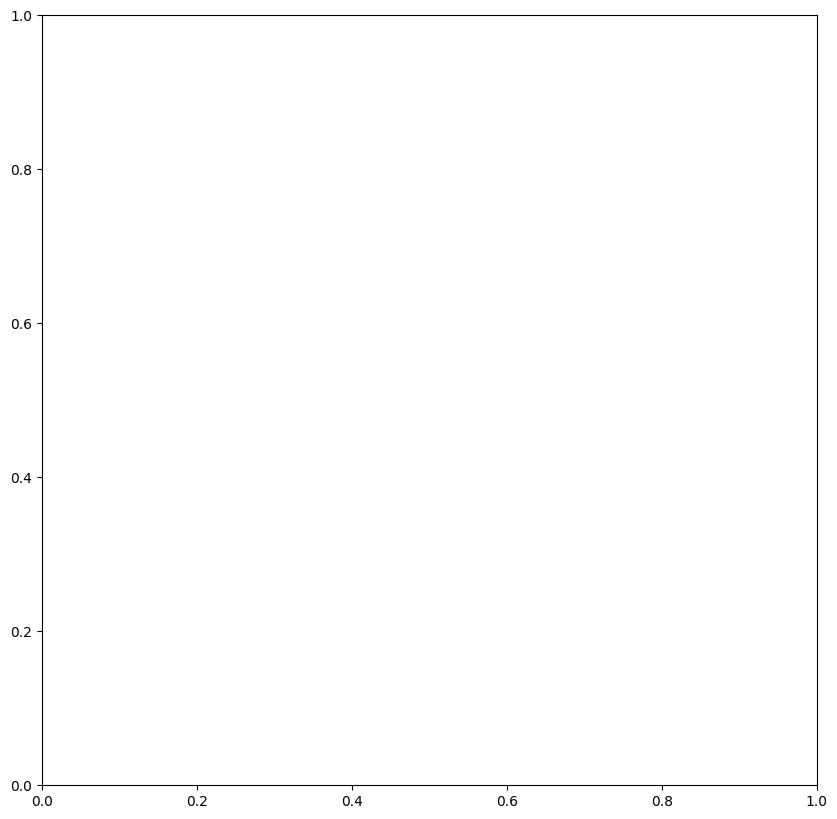

In [ ]:
fig_1, ax_1= plt.subplots(figsize=(10, 10))

og_farm = gpd.read_file(farm_shp_dir)
transformed_farm_gdf = gpd.read_file("output/farm_transformed_crs.shp")
gemeente_gdf = gpd.read_file(gemeente_shp_dir)

gemeente_gdf.plot(ax=ax_1, color='orange',  markersize=1.5)

og_farm.plot(ax=ax_1, color='red',  markersize=1.5)
transformed_farm_gdf.plot(ax=ax_1, color='red', markersize=1.5)

plt.title("Plot of farm data before and after preprocessing")

### Plot to check if farms outside NL were discarded

In [ ]:
fig_2, ax_2 = plt.subplots(figsize=(10, 10))

preprocessed_farm_gdf = gpd.read_file(preprocessed_farm_shp_dir)

gemeente_gdf.plot(ax=ax_2, color="blue", alpha=0.3)
preprocessed_farm_gdf.plot(ax=ax_2, color='red', markersize=0.5)
plt.title("Plot of preprocessed farm data and gemeente shp")

### Plot to check if farms have correct gemeente IDs

In [ ]:
fig_3, ax_3 = plt.subplots(figsize=(10, 10))
selected_gemeented_id = 333

selected_gemeente = gemeente_gdf[gemeente_gdf["OBJECTID"] == selected_gemeented_id]
farms_in_gm = preprocessed_farm_gdf[preprocessed_farm_gdf["gm_id"]==selected_gemeented_id]

gemeente_gdf.plot(ax=ax_3, color="blue", alpha=0.1)
selected_gemeente.plot(ax=ax_3, color="black")
farms_in_gm.plot(ax=ax_3, color='yellow', markersize=1.5)

plt.title(f"Plot of preprocessed farms with gemeente ID {selected_gemeented_id}")

In [ ]:
gemeente_gdf.columns